In [877]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings("ignore")

In [878]:
def split_train_test(x, y, train_size=0.8, random_state=42):
    train_set_size = int(len(x) * train_size)
    
    np.random.seed(random_state)
    shuffled_indices = np.random.permutation(len(x))
        
    train_indices = shuffled_indices[:train_set_size]
    test_indices = shuffled_indices[train_set_size:]
    
    return x.iloc[train_indices], x.iloc[test_indices], y.iloc[train_indices], y.iloc[test_indices]

## Data Transformation

In [879]:
titanic_data = pd.read_csv("./input/titanic_survival.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [880]:
titanic_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [881]:
titanic_data = titanic_data.drop(columns=["Name", "PassengerId", "Ticket", "Cabin"])

age_median = titanic_data["Age"].median()
titanic_data["Age"] = titanic_data["Age"].fillna(age_median)

embarked_mode = titanic_data["Embarked"].mode()[0]
titanic_data["Embarked"] = titanic_data["Embarked"].fillna(embarked_mode)

titanic_data = pd.get_dummies(titanic_data, columns=["Sex", "Embarked"], drop_first=True, dtype=int)

titanic_data.isna().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [882]:
x_train, x_test, y_train, y_test = split_train_test(titanic_data.drop("Survived", axis=1), titanic_data["Survived"])
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 8), (179, 8), (712,), (179,))

In [883]:
def z_score(x):
    return (x - x.mean()) / x.std(ddof=1)

In [884]:
x_train = z_score(x_train)
x_test = z_score(x_test)

In [885]:
x_train.describe()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.995907e-17,1.496930e-16,-9.979533e-18,1.097749e-16,5.738231e-17,9.231068e-17,-7.484650e-17,1.447032e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.576792e+00,-2.155855e+00,-4.816300e-01,-4.934827e-01,-6.303667e-01,-1.345987e+00,-3.086270e-01,-1.593335e+00
25%,-3.760690e-01,-5.408570e-01,-4.816300e-01,-4.934827e-01,-4.789913e-01,-1.345987e+00,-3.086270e-01,-1.593335e+00
50%,8.246536e-01,-9.183072e-02,-4.816300e-01,-4.934827e-01,-3.534022e-01,7.419057e-01,-3.086270e-01,6.267327e-01
75%,8.246536e-01,4.320333e-01,4.451824e-01,7.056972e-01,-3.692245e-02,7.419057e-01,-3.086270e-01,6.267327e-01
max,8.246536e-01,3.799731e+00,6.932869e+00,6.701597e+00,9.155634e+00,7.419057e-01,3.235606e+00,6.267327e-01


In [886]:
x_survived = x_train[y_train == 1]
x_died = x_train[y_train == 0]

## Data Exploration Visualizations

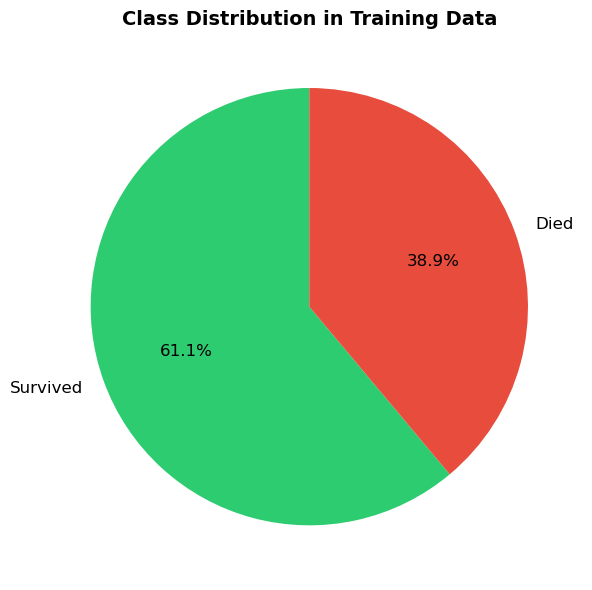

Survived: 277 (38.9%)
Died: 435 (61.1%)


In [887]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

survived_counts = y_train.value_counts()
labels = ["Survived", "Died"]
colors = ["#2ecc71", "#e74c3c"]

ax.pie(survived_counts.values, labels=labels, autopct="%1.1f%%", 
       colors=colors, startangle=90, textprops={"fontsize": 12})
ax.set_title("Class Distribution in Training Data", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Survived: {survived_counts[1]} ({survived_counts[1]/len(y_train)*100:.1f}%)")
print(f"Died: {survived_counts[0]} ({survived_counts[0]/len(y_train)*100:.1f}%)")

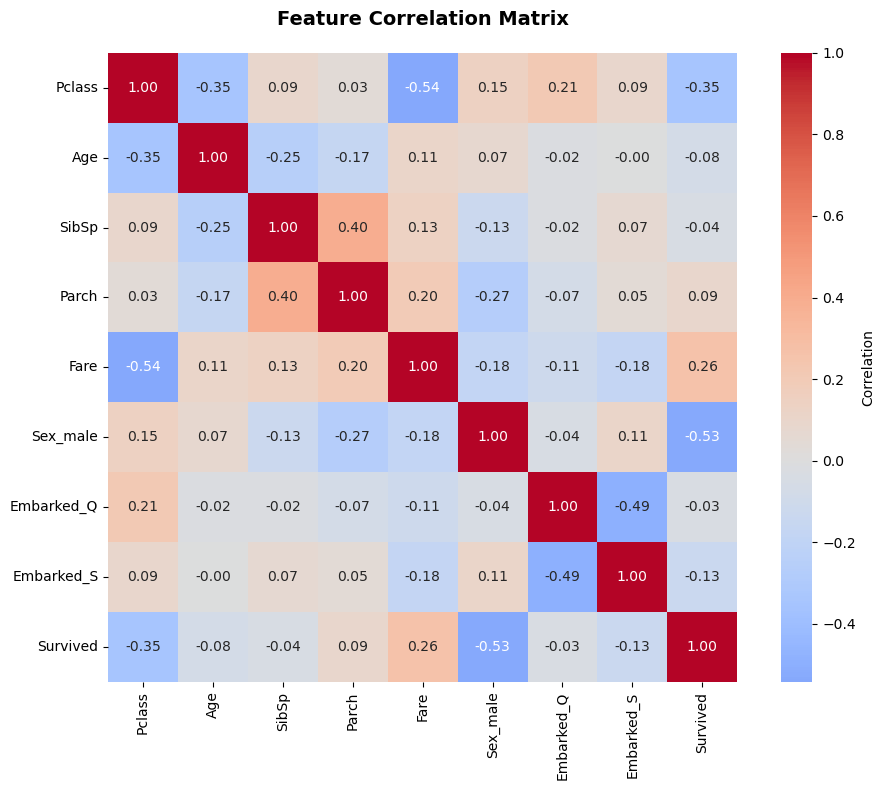

In [888]:
fig, ax = plt.subplots(figsize=(10, 8))

correlation_data = x_train.copy()
correlation_data["Survived"] = y_train.values

correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

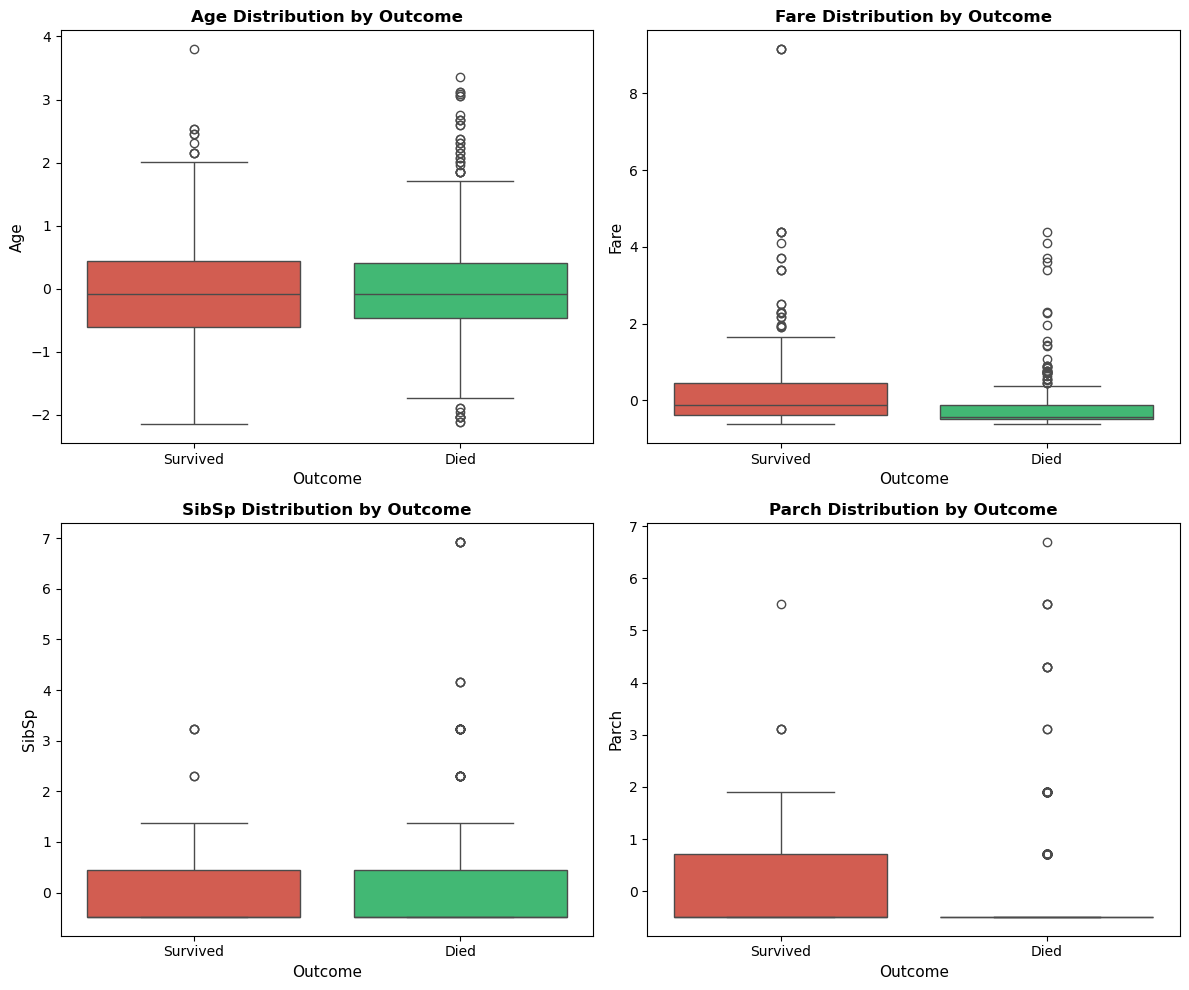

In [889]:
numeric_features = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

viz_data = x_train.copy()
viz_data["Survived"] = y_train.values
viz_data["Outcome"] = viz_data["Survived"].map({1: "Survived", 0: "Died"})

for idx, feature in enumerate(numeric_features):
    sns.boxplot(data=viz_data, x="Outcome", y=feature, ax=axes[idx], 
                palette=["#e74c3c", "#2ecc71"])
    axes[idx].set_title(f"{feature} Distribution by Outcome", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Outcome", fontsize=11)
    axes[idx].set_ylabel(feature, fontsize=11)

plt.tight_layout()
plt.show()

## Model Building

In [890]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [891]:
def predict(x, k=5):
    distances = []
    
    for i in range (len(x_train)):
        distances.append({"idx": i, "dist": math.dist(x, x_train[i])})
    
    distances = sorted(distances, key=lambda d: d["dist"])
    neighbors = distances[:k]
    
    neighbor_indices = [neighbor["idx"] for neighbor in neighbors]
    neighbor_labels = y_train[neighbor_indices]
    
    values, counts = np.unique(neighbor_labels, return_counts=True)
    
    return values[np.argmax(counts)]

## Model Evaluation

In [892]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [893]:
predictions = []

for x in x_test:
    prediction = predict(x, 4)
    predictions.append(prediction)

predictions = np.array(predictions)

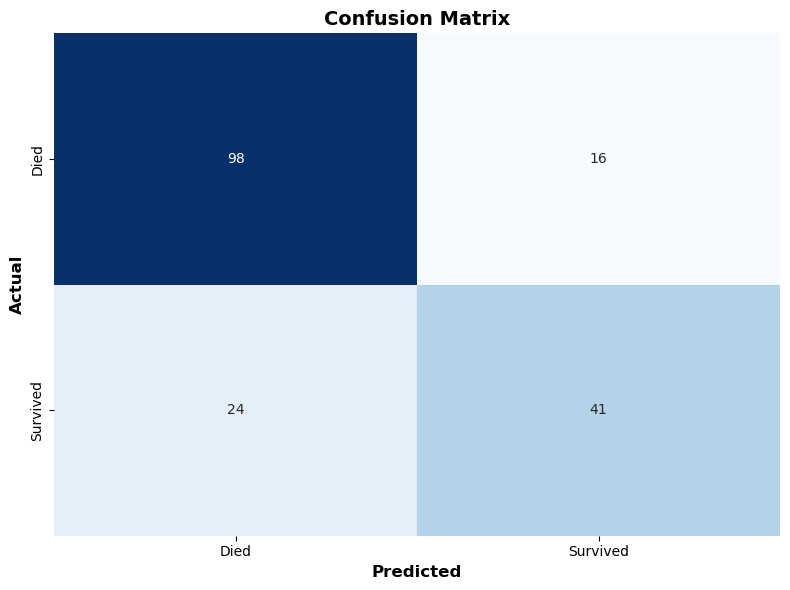

True Negatives: 98
False Positives: 16
False Negatives: 24
True Positives: 41

Sensitivity (Recall): 0.6308
Specificity: 0.8596
Precision: 0.7193


In [894]:
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn_val, fp_val, fn_val, tp_val = cm.ravel()
sensitivity = tp_val / (tp_val + fn_val)
specificity = tn_val / (tn_val + fp_val)
precision = tp_val / (tp_val + fp_val)

print(f"True Negatives: {tn_val}")
print(f"False Positives: {fp_val}")
print(f"False Negatives: {fn_val}")
print(f"True Positives: {tp_val}")
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")

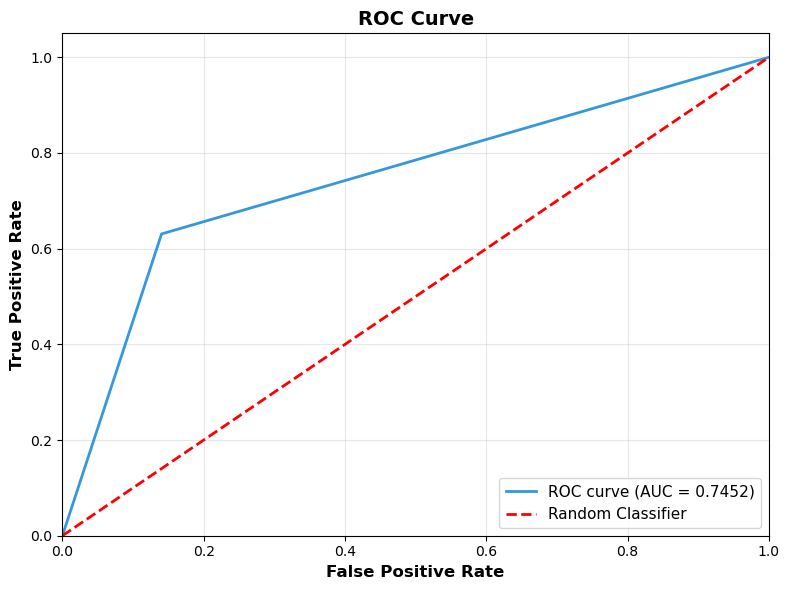

Area Under the Curve (AUC): 0.7452


In [895]:
fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")